In [1]:
# 1. 멀티스레딩을 이용한 로그 파일 병렬 읽기
# 2. 단일 쓰레드 vs 멀티 쓰레드 처리시간 비교

In [2]:
import os
import time
import concurrent.futures
import matplotlib.pyplot as plt

In [7]:
LOG_DIR = './data/log_files'

os.makedirs(LOG_DIR, exist_ok=True)

for i in range(10000):
    file_path = os.path.join(LOG_DIR, f'log_{i}.txt')
    if not os.path.exists(file_path):
        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(("Sensor Value : " + str(i) + "\n") * 40000)

files = [os.path.join(LOG_DIR, f) for f in os.listdir(LOG_DIR)]

In [8]:
# 파일 읽이오기
def read_file(path:str) -> str:
    with open(path, 'r', encoding='utf-8') as f: # 읽기 모드로 파일가져오기
        content = f.read() # 파일 전체 내용 읽어온다
    return content # 읽은 내용을 호출한 쪽에 반환


# 단일 쓰레드
start_single = time.time()
for path_ in files: # 파일을 순차적으로 읽어옴
    _ = read_file(path_)
end_single = time.time()
elapsed_single = end_single - start_single

print(f"단일 쓰레드 처리시간 : {elapsed_single:.4f}초")

단일 쓰레드 처리시간 : 98.2064초


In [9]:
# 멀티 쓰레드
start_multi = time.time()

with concurrent.futures.ThreadPoolExecutor() as executor:
    list(executor.map(read_file, files)) # executor.map 으로 read_file 함수를 file 모곩에 병렬로 적용
end_multi = time.time()
elapsed_multi = end_multi - start_multi

print(f"멀티 쓰레드 처리 시간 : {elapsed_multi:.4f}초")

멀티 쓰레드 처리 시간 : 25.9223초


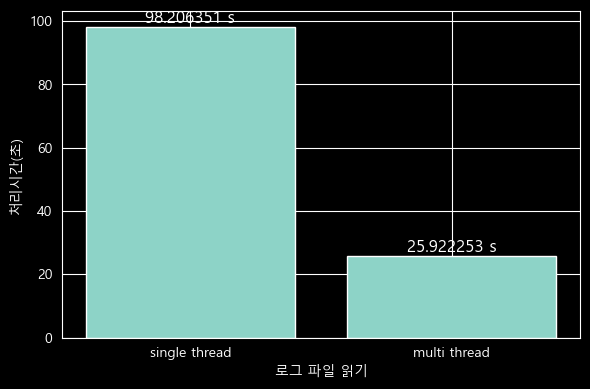

In [10]:
from matplotlib import font_manager,rc
plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams['axes.unicode_minus'] = False

# 성능 비교 시각화
labels = ['single thread','multi thread']
times = [elapsed_single, elapsed_multi]

plt.figure(figsize=[6,4])
plt.bar(labels, times)
plt.ylabel('처리시간(초)')
plt.xlabel('로그 파일 읽기')

for i, v in enumerate(times):
    plt.text(i,v, f'{v:3f} s', ha = 'center', va = 'bottom', fontsize = 12)

plt.tight_layout()
plt.show()